In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [134]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

In [135]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

In [136]:
## 컬럼명 변경
# merchant_df 컬럼명 변경
merchant_df.columns = ['가맹점구분번호', '가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일', '폐업일']

# sale_df 컬럼명 변경
sale_df.columns = ['가맹점구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간', '배달매출금액 비율', 
                   '동일 업종 매출금액 비율', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중']

# cust_df 컬럼명 변경
cust_df.columns = ['가맹점구분번호', '기준년월', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', 
                   '재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']

In [137]:
## merchant_df 전처리
# 복사본 생성
merchant_df_prc = merchant_df.copy()

## 업종 그룹화 
meat = ['한식-육류/고기',  '꼬치구이']
cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
enter = ['일반 유흥주점',  '룸살롱/단란주점']
convenience = ['샌드위치/토스트',  '도시락', '분식']
world_food = ['동남아/인도음식',  '기타세계요리']
dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품', '건강원', '담배',  '식료품']

# replace 진행
groups_to_replace = [(meat, 'meat'), (cafe, 'cafe'), (k_food, 'k_food'), (w_food, 'w_food'), (j_food, 'j_food'),
                        (c_food, 'c_food'), (drink, 'drink'), (product, 'product'), (enter, 'enter'), (convenience, 'convenience'),
                        (world_food, 'world_food'), (dessert, 'dessert'), (others, 'others')]

replacement = {}
for ind, cat in groups_to_replace:
    for i in ind:
        replacement[i] = cat

merchant_df_prc['업종'].replace(replacement, inplace=True)

## 상권 그룹화
# 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                    '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                    '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}

merchant_df_prc['상권'].replace(areas_to_replace, inplace=True)

# 상권 결측치는 Unknown으로 대체
merchant_df_prc['상권'].fillna('Unknown', inplace=True)

## 상권 결측치 대체
merchant_df_prc.loc[merchant_df_prc['상권']=='Unknown', '가맹점주소'].str.split(expand=True)[2].value_counts()
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 410')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로31')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장로 137')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('무학로 33')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장로35길')), '상권'] = '마장동'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장로37길')), '상권'] = '마장동'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장')), '상권'] = '마장동'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('금호로')), '상권'] = '신금호'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('행당로')), '상권'] = '행당'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 58')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점구분번호'].str.contains('1F0AADBBB8')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 16')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로14')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('동일로')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('광나루로')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('아차산로')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('매봉길')), '상권'] = '옥수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('옥수2동')), '상권'] = '옥수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('연무장')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('성덕정')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('서울숲2길')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('무학봉길')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('송정')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('성수')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('둘레1길')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('독서당로')), '상권'] = '행당'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 50')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 6')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('무학')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('난계로')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('홍익동')), '상권'] = '왕십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('살곶이')), '상권'] = '한양대'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마조로')), '상권'] = '한양대'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('사근동')), '상권'] = '한양대'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로 3')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로1가')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로1길')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('서울숲길')), '상권'] = '뚝섬'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('선릉')), '상권'] = '성수'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('고산자로')), '상권'] = '행당'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('응봉동')), '상권'] = '행당'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('장터')), '상권'] = '금남시장'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('동호')), '상권'] = '금남시장'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('청계천')), '상권'] = '마장동'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('금호')), '상권'] = '신금호'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('자동차시장길')), '상권'] = '답십리'
merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('용답')), '상권'] = '답십리'

# 불필요 컬럼 제거
merchant_df_prc.drop('가맹점지역', axis=1, inplace=True)

In [138]:
## sale_df 전처리
# 복사본 생성
sale_df_prc = sale_df.copy()

# 구간 데이터 앞에 숫자만 빼오기
sale_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'] = sale_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].apply(lambda x: x.str.split('_', expand=True)[0])

# 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
# 가정: 결측값의 경우 취소율이 적다고 판단!!
band_cols = sale_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].columns
sale_df_prc[band_cols] = sale_df_prc[band_cols].fillna(1).astype(int)

## 비율 데이터 전처리
# 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
sale_df_prc['배달매출금액 비율'] = sale_df_prc['배달매출금액 비율'].map(lambda x: 0 if x < 0 else x)

# 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
sale_df_prc['동일 상권 내 해지 가맹점 비중'] = sale_df_prc['동일 상권 내 해지 가맹점 비중'].map(lambda x: 0 if x < 0 else x)

In [139]:
## cust_df 전처리 
# 복사본 생성
cust_df_prc = cust_df.copy()

# 결측치는 0으로 대체
cust_cols = cust_df_prc.iloc[:, 2:].columns
cust_df_prc[cust_cols] = cust_df_prc[cust_cols].clip(lower=0)

#  100 - (첫방문 비율 + 재방문 비율) 나타내는 컬럼 추가
cust_df_prc['신규 재방문 외 고객'] = 100 - (cust_df_prc['재방문 고객 비중'] + cust_df_prc['신규 고객 비중'])

# visit 관련 컬럼끼리 보기 편하게 컬럼 순서 조정
cust_df_prc = cust_df_prc[['가맹점구분번호', '기준년월', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중',
                       '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중', '신규 고객 비중', '신규 재방문 외 고객', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']]

In [140]:
# 세 DataFrame Merge
merged_df = merchant_df_prc.merge(sale_df_prc, on='가맹점구분번호').merge(cust_df_prc, on=['가맹점구분번호', '기준년월'])

# EDA

In [141]:
merchant_df_prc.상권.value_counts()

상권
성수      1077
왕십리      807
뚝섬       528
마장동      411
한양대      368
금남시장     270
답십리      228
행당       215
신금호      150
옥수       131
Name: count, dtype: int64

In [142]:
merchant_df_prc.loc[merchant_df_prc['상권']=='뚝섬', '업종'].value_counts()

업종
k_food         119
cafe           111
w_food          70
meat            41
drink           36
j_food          34
dessert         32
convenience     23
others          22
c_food          13
world_food      12
enter            8
product          7
Name: count, dtype: int64

# Feature Engineering

In [143]:
# 영업 시작일자 빠른 순으로 가맹점별 거래 시간순 정렬
sorted_df = merged_df.sort_values(['개설일', '가맹점구분번호', '기준년월']).reset_index(drop=True)

In [144]:
# 날짜 데이터 datetime 객체로 변환
# 일(day)은 모두 1로 통일
sorted_df['기준년월'] = pd.to_datetime(sorted_df['기준년월'], format='%Y%m').dt.to_period('M').dt.to_timestamp()
sorted_df['개설일'] = pd.to_datetime(sorted_df['개설일'], format='%Y%m%d').dt.to_period('M').dt.to_timestamp()
sorted_df['폐업일'] = pd.to_datetime(sorted_df['폐업일'], format='%Y%m%d').dt.to_period('M').dt.to_timestamp()

In [145]:
# 영업 개월수 계산
sorted_df['operation'] = sorted_df['기준년월'].dt.to_period('M').astype(int) - sorted_df['개설일'].dt.to_period('M').astype(int)

In [146]:
sale_df_prc['매출금액 구간'].transform(lambda x: x.shift(1) - x.shift(2))

0        NaN
1        NaN
2        1.0
3       -3.0
4        0.0
        ... 
86585    0.0
86586    0.0
86587    0.0
86588    0.0
86589    0.0
Name: 매출금액 구간, Length: 86590, dtype: float64

In [147]:
## 이동평균 계산
# shift(1) : 이전 달부터(자기 자신 제외)
# rolling(window=6, min_periods=3).mean() : 이전 6개월 간의 평균 계산, 이전 데이터는 최소 3개월 분 존재해야 하며, 이보다 적을 시 nan 반환

# 매출 구간
sorted_df['매출금액 구간_6'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
# sorted_df['매출금액 구간_1'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(1) - x.shift(2))
sorted_df['매출금액 구간_std'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(1).rolling(window=3, min_periods=2).std())

# 매출 건수
# sorted_df['매출건수 구간_6'] = sorted_df.groupby('가맹점구분번호')['매출건수 구간'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
# sorted_df['매출건수 구간_1'] = sorted_df.groupby('가맹점구분번호')['매출건수 구간'].transform(lambda x: x.shift(1) - x.shift(2))
# sorted_df['매출건수 구간_std'] = sorted_df.groupby('가맹점구분번호')['매출건수 구간'].transform(lambda x: x.shift(1).rolling(window=3, min_periods=2).std())

# 유니크 고객 수
sorted_df['유니크 고객 수 구간_6'] = sorted_df.groupby('가맹점구분번호')['유니크 고객 수 구간'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
# sorted_df['유니크 고객 수 구간_1'] = sorted_df.groupby('가맹점구분번호')['유니크 고객 수 구간'].transform(lambda x: x.shift(1) - x.shift(2))
sorted_df['유니크 고객 수 구간_std'] = sorted_df.groupby('가맹점구분번호')['유니크 고객 수 구간'].transform(lambda x: x.shift(1).rolling(window=3, min_periods=2).std())

# 객단가 
sorted_df['객단가 구간_6'] = sorted_df.groupby('가맹점구분번호')['객단가 구간'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

# 취소율
sorted_df['취소율 구간_6'] = sorted_df.groupby('가맹점구분번호')['취소율 구간'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

# 배달 매출금액 비율
sorted_df['배달매출금액 비율_6'] = sorted_df.groupby('가맹점구분번호')['배달매출금액 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

# 고객 형태 변화율
sorted_df['거주 이용 고객 비율_6'] = sorted_df.groupby('가맹점구분번호')['거주 이용 고객 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['직장 이용 고객 비율_6'] = sorted_df.groupby('가맹점구분번호')['직장 이용 고객 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['유동인구 이용 고객 비율_6'] = sorted_df.groupby('가맹점구분번호')['유동인구 이용 고객 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

sorted_df['재방문 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['재방문 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['신규 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['신규 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

sorted_df['남성 20대이하 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['남성 20대이하 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['남성 30대 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['남성 30대 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['남성 40대 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['남성 40대 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['남성 50대 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['남성 50대 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['남성 60대이상 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['남성 60대이상 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['여성 20대이하 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['여성 20대이하 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['여성 30대 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['여성 30대 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['여성 40대 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['여성 40대 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['여성 50대 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['여성 50대 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['여성 60대이상 고객 비중_6'] = sorted_df.groupby('가맹점구분번호')['여성 60대이상 고객 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

# 동일 업종 내 매출 비율
sorted_df['동일 업종 매출금액 비율_6'] = sorted_df.groupby('가맹점구분번호')['동일 업종 매출금액 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

# 동일 업종 내 매출 순위
sorted_df['동일 업종 내 매출 순위 비율_6'] = sorted_df.groupby('가맹점구분번호')['동일 업종 내 매출 순위 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['동일 업종 내 매출 순위 비율_std'] = sorted_df.groupby('가맹점구분번호')['동일 업종 내 매출 순위 비율'].transform(lambda x: x.shift(1).rolling(window=3, min_periods=2).std())
sorted_df['동일 업종 내 매출 순위 비율_1'] = sorted_df.groupby('가맹점구분번호')['동일 업종 내 매출 순위 비율'].transform(lambda x: x.shift(1) - x.shift(2))
sorted_df['동일 업종 내 매출 순위 비율_diff'] = sorted_df.groupby('가맹점구분번호')['동일 업종 내 매출 순위 비율'].transform(lambda x: x.shift(1) - x.shift(1).rolling(window=3, min_periods=2).mean())

# 동일 상권 내 매출 순위
sorted_df['동일 상권 내 매출 순위 비율_6'] = sorted_df.groupby('가맹점구분번호')['동일 상권 내 매출 순위 비율'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())
sorted_df['동일 상권 내 매출 순위 비율_std'] = sorted_df.groupby('가맹점구분번호')['동일 상권 내 매출 순위 비율'].transform(lambda x: x.shift(1).rolling(window=3, min_periods=2).std())

# 동일 상권 내 폐업률
sorted_df['동일 상권 내 해지 가맹점 비중_6'] = sorted_df.groupby('가맹점구분번호')['동일 상권 내 해지 가맹점 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

# 동일 업종 내 폐업률
sorted_df['동일 업종 내 해지 가맹점 비중_6'] = sorted_df.groupby('가맹점구분번호')['동일 업종 내 해지 가맹점 비중'].transform(lambda x: x.shift(1).rolling(window=6, min_periods=3).mean())

## 12개월 전 대비 성장률
sorted_df['growth'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: (x / x.shift(12)) - 1)

In [148]:
sorted_df['매출금액 구간_1'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].diff(1)
sorted_df['매출건수 구간_1'] = sorted_df.groupby('가맹점구분번호')['매출건수 구간'].diff(1)
sorted_df['유니크 고객 수 구간_1'] = sorted_df.groupby('가맹점구분번호')['유니크 고객 수 구간'].diff(1)

sorted_df['지수평활이동평균'] = sorted_df['매출금액 구간'].ewm(span=6, adjust=False).mean()
sorted_df['지수평활변화량'] = sorted_df['지수평활이동평균'].diff(1)

In [149]:
## 가맹점 여부 컬럼 추가
# sorted_df['is_brand'] = sorted_df['브랜드구분코드'].notna().astype(int)

거래데이터 8개 미만인 가맹점 342개 제거
- 2023년 8월 이전 폐업으로 8개 미만인 가맹점 7개
- 2024년 6월부터 개업으로 8개 미만인 가맹점 335개

In [259]:
## 임시
temp = sorted_df.groupby('가맹점구분번호').filter(lambda x: len(x) >= 8).copy()
temp['임시'] = temp.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(-7))
temp['매출차이'] = temp['임시'] - temp['매출금액 구간']
temp = temp.dropna(subset=['매출차이'])
temp['급락여부'] = (temp['매출차이']>=1).astype(int)
temp.drop(['임시', '매출차이'], axis=1, inplace=True)
temp.reset_index(drop=True, inplace=True)

In [251]:
# temp.loc[(temp['임시'].isna()) & (temp['기준년월']<'2024-06-01'), ['가맹점구분번호', '가맹점명', '개설일', '폐업일', '기준년월', '임시']].head(50)
# temp['임시']

In [252]:
## 급락여부 생성
# 7개월 후 매출 구간이 현재보다 1구간 이상 떨어진 경우를 급락(1)으로 정의
# sorted_df['급락여부'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(-7) - x >= 1)

# 7개월 후 매출 구간이 현재보다 2구간 이상 떨어진 경우를 급락(1)으로 정의
# sorted_df['급락여부'] = sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: (x.shift(-7) - x >= 2).astype(int))

# ## 급락여부 생성 (Version 2)
# # 1. t+7 시점 급락 조건: t+7 구간이 t 시점 구간보다 1 이상 높음 (매출 감소)
# condition_t_plus_7 = (sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(-7) - x) >= 1)

# # 2. t+8 시점 급락 유지 조건: t+8 구간이 t 시점 구간보다 1 이상 높음 (감소 유지)
# condition_t_plus_8 = (sorted_df.groupby('가맹점구분번호')['매출금액 구간'].transform(lambda x: x.shift(-8) - x) >= 1)

# # 3. 최종 타겟: 두 조건이 모두 True일 때 1, 아니면 0
# sorted_df['급락여부'] = (condition_t_plus_7 & condition_t_plus_8).astype(int)

In [261]:
sorted_df = temp.copy()
# 급락여부 value 비율 확인
sorted_df.loc[sorted_df['개설일']<'2023-12-01', '급락여부'].value_counts(normalize=True)

급락여부
0    0.801893
1    0.198107
Name: proportion, dtype: float64

In [262]:
features = ['operation', '매출금액 구간', '매출금액 구간_6', '유니크 고객 수 구간_6', '지수평활이동평균', '지수평활변화량',
            '배달매출금액 비율_6', '동일 업종 매출금액 비율_6', '거주 이용 고객 비율_6', '직장 이용 고객 비율_6', '유동인구 이용 고객 비율_6', '취소율 구간_6', 
            '재방문 고객 비중_6', '신규 고객 비중_6',
            '동일 업종 내 매출 순위 비율_6', '동일 상권 내 매출 순위 비율_6', '동일 업종 내 매출 순위 비율_std', '동일 상권 내 매출 순위 비율_std',
            '남성 20대이하 고객 비중_6', '남성 30대 고객 비중_6',  '남성 40대 고객 비중_6', '남성 50대 고객 비중_6', '남성 60대이상 고객 비중_6', '여성 20대이하 고객 비중_6', '여성 30대 고객 비중_6',  '여성 40대 고객 비중_6', '여성 50대 고객 비중_6', '여성 60대이상 고객 비중_6',
            '동일 상권 내 해지 가맹점 비중_6',
            '동일 업종 내 매출 순위 비율_1', '동일 업종 내 매출 순위 비율_diff', '급락여부']

# Version 1
train_df = sorted_df.loc[sorted_df['기준년월']<'2024-01-01', features].reset_index(drop=True)
val_df = sorted_df.loc[(sorted_df['기준년월'] >= '2024-01-01') & (sorted_df['기준년월']<='2024-05-31'), features].reset_index(drop=True)
## 훈련데이터 수를 더 늘려도 큰 차이 없고 오히려 감소...

# Version 2
# train_df = sorted_df.loc[sorted_df['기준년월']<'2023-11-01', features].reset_index(drop=True)
# val_df = sorted_df.loc[(sorted_df['기준년월'] >= '2023-12-01') & (sorted_df['기준년월']<='2024-04-30'), features].reset_index(drop=True)

In [191]:
# sorted_df.loc[sorted_df['가맹점구분번호']=='1E00B3CC15']

In [192]:
# sorted_df.loc[sorted_df['폐업일'] < '2024-07-01']

In [266]:
X_train, y_train = train_df.drop('급락여부', axis=1), train_df['급락여부']
X_val, y_val = val_df.drop('급락여부', axis=1), val_df['급락여부']

In [267]:
# sorted_df.loc[(sorted_df['기준년월'] >= '2023-12-01') & (sorted_df['기준년월']<='2024-05-31') & (sorted_df['폐업일'].notna())].sort_values('폐업일')

In [268]:
# from sklearn.model_selection import KFold
# import category_encoders as ce

# def safe_급락여부_encode(X_train, y_train, X_val, cols, n_splits=5):
#     """
#     K-Fold 교차 검증을 사용하여 훈련 데이터에 안전하게 급락여부 Encoding을 적용하고
#     검증 데이터에 적용할 평균 인코더를 반환합니다.
#     """
    
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     # 인코딩 결과 컬럼을 저장할 데이터프레임 초기화 (결측치 방지)
#     X_train_encoded = X_train.copy()
    
#     # ------------------- 1. 훈련 데이터 인코딩 (CV) -------------------
#     # 데이터 유출 방지: 각 폴드를 인코딩할 때, 나머지 폴드의 급락여부 평균만 사용
#     for train_index, valid_index in kf.split(X_train):
#         X_fit, X_val_fold = X_train.iloc[train_index], X_train.iloc[valid_index]
#         y_fit = y_train.iloc[train_index]
        
#         # 각 폴드마다 급락여부Encoder 초기화 및 훈련
#         encoder = ce.급락여부Encoder(cols=cols)
#         encoder.fit(X_fit, y_fit)
        
#         # 유효성 검사 폴드에 인코딩 결과 적용
#         # 인덱스 유지를 위해 원본 인덱스에 맞춰 재할당
#         X_train_encoded.loc[X_val_fold.index, cols] = encoder.transform(X_val_fold)[cols]

#     for col in cols:
#         # object 타입을 float64로 강제 변환
#         X_train_encoded[col] = pd.to_numeric(X_train_encoded[col], errors='coerce').astype('float64') 

#     # ------------------- 2. 검증/테스트 데이터용 최종 인코더 -------------------
#     # 검증/테스트 데이터에 적용할 최종 인코더를 전체 훈련 데이터로 훈련
#     final_encoder = ce.급락여부Encoder(cols=cols)
#     final_encoder.fit(X_train, y_train)
    
#     # 검증 데이터에 최종 인코더 적용
#     X_val_encoded = final_encoder.transform(X_val)
    
#     for col in cols:
#         # object 타입을 float64로 강제 변환
#         X_train_encoded[col] = pd.to_numeric(X_train_encoded[col], errors='coerce').astype('float64') 
    
#     # X_train은 인코딩된 X_train_encoded로 대체하고, y_train은 유지
#     return X_train_encoded, X_val_encoded

# # # --- 사용 예시 ---
# 급락여부_ENCODE_COLS = ['업종', '상권'] # 인코딩할 컬럼 리스트

# X_train, X_val = safe_급락여부_encode(X_train, y_train, X_val, 급락여부_ENCODE_COLS)

# # # 안전한 급락여부 Encoding 실행
# # X_train_te, X_val_te = safe_급락여부_encode(X_train, y_train, X_val, 급락여부_ENCODE_COLS)

# # # X_train, X_val에 급락여부 Encoding 결과를 병합하거나 교체합니다.
# # # (만약 원-핫 인코딩을 사용할 다른 범주형 컬럼이 있다면 병합해야 함)

In [270]:
# from sklearn.preprocessing import OneHotEncoder

# ohe = OneHotEncoder(sparse_output=False)
# train_encoded_df = ohe.fit_transform(X_train[['업종', '상권']])
# train_encoded_df = pd.DataFrame(train_encoded_df, columns=ohe.get_feature_names_out())
# X_train = pd.concat([X_train, train_encoded_df], axis=1).drop(['업종', '상권'], axis=1)

# val_encoded_df = ohe.transform(X_val[['업종', '상권']])
# val_encoded_df = pd.DataFrame(val_encoded_df, columns=ohe.get_feature_names_out())
# X_val = pd.concat([X_val, val_encoded_df], axis=1).drop(['업종', '상권'], axis=1)

In [271]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score

In [272]:
pos_weight = ((y_train==0).sum()) / ((y_train==1).sum())

In [273]:
xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, scale_pos_weight=((y_train==0).sum()) / ((y_train==1).sum()), random_state=11)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [274]:
lgb = LGBMClassifier(n_estimators=500, learning_rate=0.05, scale_pos_weight=((y_train==0).sum()) / ((y_train==1).sum()), verbose=-1, random_state=11)

lgb.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [275]:
# params = {
#     'learning_rate': [0.03, 0.05, 0.1],
#     'max_depth': [3, 5, 7, 9],
#     'min_child_weight': [1, 5, 10, 20],
# }

# gs = GridSearchCV(xgb, param_grid=params, cv=5, scoring='f1')
# gs.fit(X_train, y_train)

In [276]:
# # GridSearchCV
# best = gs.best_estimator_
# pred = best.predict_proba(X_val)[:, 1]
# pred = (pred > 0.52).astype(int)
# print(f'prcision score: {precision_score(y_val, pred)}')
# print(f'recall score: {recall_score(y_val, pred)}')
# print(f'f1 score: {f1_score(y_val, pred)}')

### 하이퍼 파라미터 튜닝

#### XGBoost

In [277]:
from sklearn.model_selection import StratifiedKFold
from hyperopt import hp, fmin, tpe, Trials

In [278]:
xgbc_search_space = {
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),
    'subsample': hp.uniform('subsample', 0.7, 1)
}

def objective_func(search_space):
    xgbc = XGBClassifier(n_estimators=500,
                          scale_pos_weight=pos_weight,
                          min_child_weight=int(search_space['min_child_weight']),
                          learning_rate=search_space['learning_rate'],
                          max_depth=int(search_space['max_depth']),
                          colsample_bytree=search_space['colsample_bytree'],
                          subsample=search_space['subsample'],
                          random_state=11)

    xgbc.fit(X_train, y_train)

    score = f1_score(y_val, xgbc.predict(X_val))

    return -score

trials = Trials()

best = fmin(fn=objective_func, space=xgbc_search_space, algo=tpe.suggest, max_evals=100,
           trials=trials, rstate=np.random.default_rng(seed=30))

print('best:', best)

100%|█████████████████████████████████████████████| 100/100 [07:24<00:00,  4.45s/trial, best loss: -0.5649905123339658]
best: {'colsample_bytree': np.float64(0.6438867539475248), 'learning_rate': np.float64(0.022631997237155796), 'max_depth': np.float64(9.0), 'min_child_weight': np.float64(9.0), 'subsample': np.float64(0.8723046641098242)}


In [279]:
xgbc = XGBClassifier(
    n_estimators=500,
    scale_pos_weight=pos_weight,
    min_child_weight=int(best['min_child_weight']),
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    colsample_bytree=round(best['colsample_bytree'], 5),
    subsample=round(best['subsample'], 5),
    random_state=11
)

xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.64389)
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [280]:
precision = []
recall = []
f1 = []

pr = xgbc.predict_proba(X_val)[:, 1]
for i in np.arange(0.3, 0.6, 0.01):
    pred = (pr > i).astype(int)
    precision.append(precision_score(y_val, pred))
    recall.append(recall_score(y_val, pred))
    f1.append(f1_score(y_val, pred))

In [281]:
print('precision: ', precision[19])
print('recall: ', recall[19])
print('f1: ', f1[19])

precision:  0.4870024370430544
recall:  0.6631637168141593
f1:  0.5615925058548009


In [208]:
max(f1)

0.5679962677863307

- 0.5705824284304047 성별 추가 전
- 0.5713520271477049 성별 추가 후
- 0.5761822949633782 성별 이동평균
- 0.5737 동일업종 폐업률
- 0.5755 동일상권 폐업률
- 0.5788493927843277 동일상권 폐업률 이동평균
- 0.5750481960892316 동일상권 폐업률 이동평균 + 동일업종 폐업률 이동평균
- 0.5772025883524141 동일 업종 이동평균 제외하고 50대 추가
- 0.5763109071379748 60대까지 추가
- 0.575889477668433 동일 업종 매출 비율을 이동평균으로 수정
- 0.5741989103333641 동일 업종 내 매출 순위 비율_std 동일 상권 내 매출 순위 비율_std 제거
- 0.572 업종명, 상권명 제거
- 0.5757720623386557 growth 제거

In [ ]:
# HypterOpt
pred = xgbc.predict_proba(X_val)[:, 1]
pred = (pred > 0.4).astype(int)
print(f'prcision score: {precision_score(y_val, pred)}')
print(f'recall score: {recall_score(y_val, pred)}')
print(f'f1 score: {f1_score(y_val, pred)}')

#### lgbm

In [ ]:
lgbm_search_space = {
    'num_leaves': hp.quniform('num_leaves', 30, 60, 1),
    'min_child_samples': hp.quniform('min_child_samples', 20, 50, 5),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 100, 160, 1),
    'sub_sample': hp.uniform('subsample', 0.7, 1)
}

def objective_func(search_space):
    lgbmc = LGBMClassifier(n_estimators=500,
                              boost_from_average=False,
                              scale_pos_weight=pos_weight,
                              num_leaves=int(search_space['num_leaves']),
                              min_child_samples=int(search_space['min_child_samples']),
                              learning_rate=search_space['learning_rate'],
                              max_depth=int(search_space['max_depth']),
                              sub_sample=search_space['sub_sample'], 
                              verbose=-1,
                              random_state=11)

    lgbmc.fit(X_train, y_train)

    score = f1_score(y_val, lgbmc.predict(X_val))

    return -score

trials = Trials()

best = fmin(fn=objective_func, space=lgbm_search_space, algo=tpe.suggest, max_evals=100,
           trials=trials, rstate=np.random.default_rng(seed=30))

print('best:', best)

In [ ]:
lgbmc = LGBMClassifier(
    n_estimators=500,
    boost_from_average=False,
    scale_pos_weight=pos_weight,
    num_leaves=int(best['num_leaves']),
    min_child_samples=int(best['min_child_samples']),
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['learning_rate']),
    subsample=round(best['learning_rate'], 5),
    random_state=11
)

lgbmc.fit(X_train, y_train)

In [ ]:
precision = []
recall = []
f1 = []

pr = lgbmc.predict_proba(X_val)[:, 1]
for i in np.arange(0.3, 0.6, 0.01):
    pred = (pr > i).astype(int)
    precision.append(precision_score(y_val, pred))
    recall.append(recall_score(y_val, pred))
    f1.append(f1_score(y_val, pred))

In [ ]:
max(f1)

In [ ]:
0.5661764705882353
0.5644397685428721

In [ ]:
# HypterOpt
pred = lgbmc.predict_proba(X_val)[:, 1]
pred = (pred > 0.4).astype(int)
print(f'prcision score: {precision_score(y_val, pred)}')
print(f'recall score: {recall_score(y_val, pred)}')
print(f'f1 score: {f1_score(y_val, pred)}')

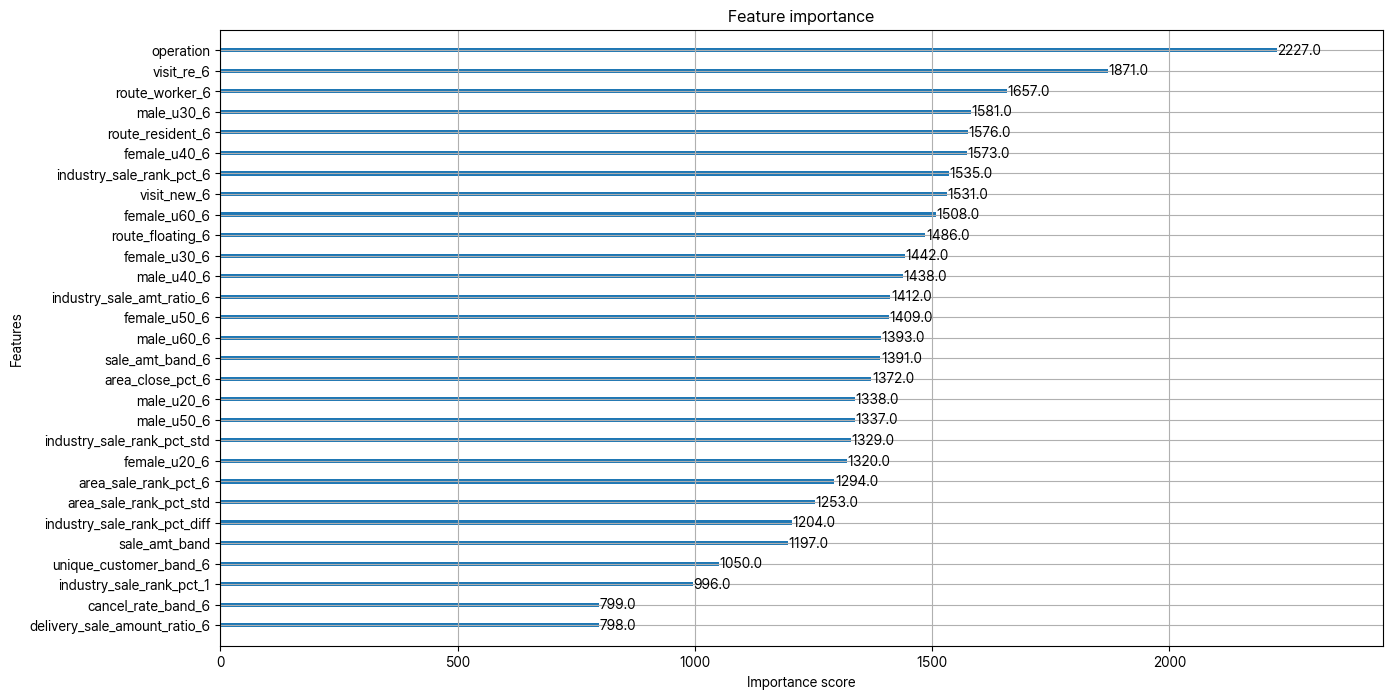

In [33]:
from xgboost import plot_importance

f, ax = plt.subplots(figsize=(15, 8))
plot_importance(xgbc, max_num_features=None, ax=ax)
plt.show()

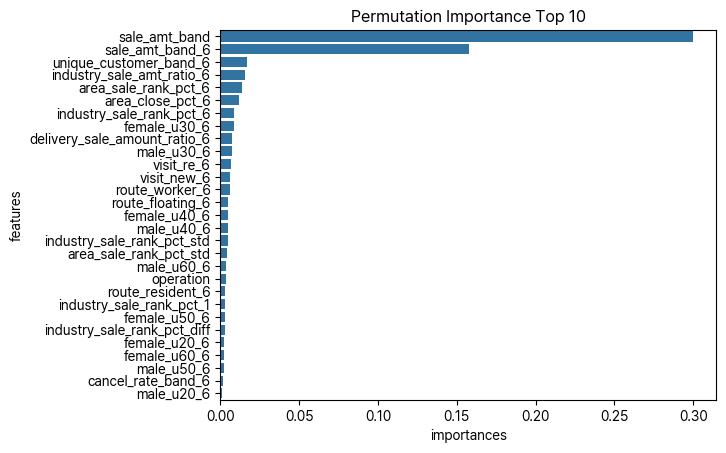

In [34]:
from sklearn.inspection import permutation_importance

result = permutation_importance(xgbc, X_val, y_val, scoring='f1', n_repeats=10, n_jobs=-1, random_state=11)
pi_df = pd.DataFrame({'features': X_val.columns, 'importances': result.importances_mean})
# top10 = pi_df.sort_values('importances', ascending=False).iloc[:10]
top10 = pi_df.sort_values('importances', ascending=False)
sns.barplot(data=top10, x='importances', y='features')
plt.title('Permutation Importance Top 10')
plt.show()

In [35]:
top10

,features,importances
1,sale_amt_band,0.299587
2,sale_amt_band_6,0.157850
3,unique_customer_band_6,0.016798
5,industry_sale_amt_ratio_6,0.015397
13,area_sale_rank_pct_6,0.013632
26,area_close_pct_6,0.011967
12,industry_sale_rank_pct_6,0.008968
22,female_u30_6,0.008469
4,delivery_sale_amount_ratio_6,0.007543
17,male_u30_6,0.007457


In [36]:
precision = []
recall = []
f1 = []

pr = best.predict_proba(X_val)[:, 1]
for i in np.arange(0.3, 0.6, 0.01):
    pred = (pr > i).astype(int)
    precision.append(precision_score(y_val, pred))
    recall.append(recall_score(y_val, pred))
    f1.append(f1_score(y_val, pred))

AttributeError: 'dict' object has no attribute 'predict_proba'

In [ ]:
np.array(f1)

In [ ]:
f, ax = plt.subplots(figsize=(12, 5))
# sns.lineplot(x=np.arange(0.3, 0.6, 0.01), y=precision, label='precision', ax=ax)
# sns.lineplot(x=np.arange(0.3, 0.6, 0.01), y=recall, label='recall', ax=ax)
sns.lineplot(x=np.arange(0.3, 0.6, 0.01), y=f1, label='f1', ax=ax)
plt.show()

In [ ]:
# XGBClassifier
pred = xgb.predict_proba(X_val)[:, 1]
pred = (pred > 0.45).astype(int)
print(f'prcision score: {precision_score(y_val, pred)}')
print(f'recall score: {recall_score(y_val, pred)}')
print(f'f1 score: {f1_score(y_val, pred)}')

In [ ]:
# LGBMClassifier
pred = lgb.predict_proba(X_val)[:, 1]
pred = (pred > 0.45).astype(int)
print(f'prcision score: {precision_score(y_val, pred)}')
print(f'recall score: {recall_score(y_val, pred)}')
print(f'f1 score: {f1_score(y_val, pred)}')

In [ ]:
pred = xgb.predict(X_val)
print(classification_report(y_val, pred))

In [ ]:
confusion_matrix(y_val, pred)

### Train, Validation, Test
- 목표: 2024년 12월을 마지막 거래로 2025년 7월(t+7) 매출 구간 2단계 감소 여부 확인
- Train => 2024년 6월까지 영업 달 t+7 데이터가 존재하는 경우. 즉, 2023년 12월 전에 개업한 가맹점 대상으로 2023년 1월부터 2023년 11월까지의 거래 데이터
- Validation => 2024년 12월까지 영업 달 t+7 데이터가 존재하는 경우. 즉, 2024년 6월 전에 개업한 가맹점 대상으로 2023년 12월부터 2024년 5월까지의 거래 데이터
- Test => 2024년 12월 데이터

In [ ]:
test_df = sorted_df.loc[sorted_df['기준년월'] == '2024-12-01', features].reset_index(drop=True)
test_df = test_df.drop('급락여부', axis=1)

# test_encoded_df = ohe.transform(test_df[['업종', '상권']])
# test_encoded_df = pd.DataFrame(test_encoded_df, columns=ohe.get_feature_names_out())
# test_df = pd.concat([test_df, test_encoded_df], axis=1).drop(['업종', '상권'], axis=1)
test_df

In [ ]:
mct_df = sorted_df.loc[sorted_df['기준년월'] == '2024-12-01', '가맹점구분번호':'폐업일'].reset_index(drop=True)
급락여부_df = pd.DataFrame(xgbc.predict(test_df), columns=['급락여부'])
result_df = pd.concat([mct_df, 급락여부_df], axis=1)

In [ ]:
result_df.loc[result_df['급락여부']==1, '업종'].value_counts(normalize=True).plot.bar()

In [ ]:
result_df.loc[result_df['급락여부']==1, '상권'].value_counts(normalize=True).plot.bar()